# Surrogate Modelling on a Small, Noisy Fleet

A second pass at the same problem as `01_surrogate_modelling.ipynb`, in the regime that
actually turns up in industrial work: **~320 intervention events across 12 assets**, not
thousands of rows.

Sample size changes which methods are correct. With a dozen assets, a single train/test
split is too noisy to interpret, model choice has to be *earned* by ablation rather than
assumed, and the uncertainty estimate stops being a nicety and becomes the whole answer.

Structure: load → EDA → features → validation design → baseline → surrogate →
uncertainty → diagnostics → score candidates → summary.

**Data is synthetic** (`src/generate.py`), seeded and reproducible.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from src import generate as G

RANDOM_STATE = 42
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
INK, ACCENT, MUTED = "#2b3a55", "#c2643f", "#8896ab"

## 1. Load the data

Historical interventions with an observed 48-hour response, plus a set of candidate actions with no target — the ones we have to score.

In [2]:
N_EVENTS, N_ASSETS, N_CAND = 320, 12, 140

df   = G.drop_oracle(G.make_history(n_events=N_EVENTS, n_assets=N_ASSETS))
cand_full = G.make_candidates(n_candidates=N_CAND, n_assets=N_ASSETS, history_events=N_EVENTS)
cand = G.drop_oracle(cand_full)

print(f"history:    {df.shape[0]} events across {df['asset_id'].nunique()} assets")
print(f"candidates: {cand.shape[0]} scenarios")
df.head(3)

history:    320 events across 12 assets
candidates: 140 scenarios


,event_id,asset_id,site_id,event_time,operating_mode,before_output_rate,before_water_fraction_pct,before_header_pressure_kpa,before_casing_pressure_kpa,before_line_pressure_kpa,...,current_cycle_min,days_since_last_change,data_quality_score,downtime_flag,facility_constraint_flag,action_delta_injection_rate,action_delta_dwell_min,action_delta_cycle_min,event_quality_label,target_delta_output_48h
0,EVT_00001,ASSET_01,SITE_5,2023-10-01,continuous_injection,15.05,54.1,2601.0,3518.0,1083.0,...,54.2,3,0.746,0,0,-0.92,0.36,-5.83,clean,-0.285
1,EVT_00002,ASSET_05,SITE_3,2023-10-05,continuous_injection,5.41,59.1,3053.0,4545.0,768.0,...,82.7,1,0.786,0,0,-1.50,-2.77,-7.31,clean,-1.477
2,EVT_00003,ASSET_10,SITE_2,2023-10-10,cyclic,7.14,31.5,2610.0,4221.0,978.0,...,62.8,27,0.852,0,0,-3.99,2.82,12.93,clean,-1.132


## 2. Data understanding and EDA

Three things decide the whole design: how much the response clusters by asset, how noisy the target is, and how much of the action space operators actually explored.

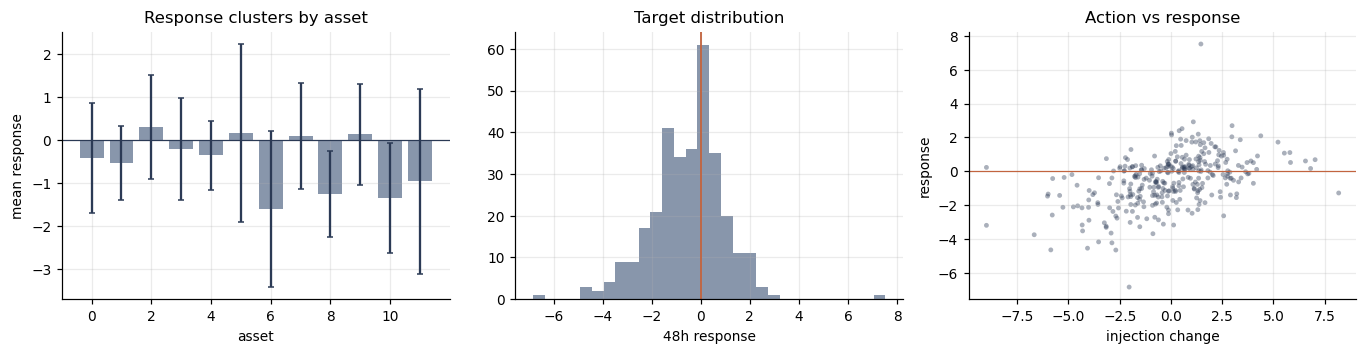

          mean   std  count
asset_id                   
ASSET_01 -0.42  1.28     25
ASSET_02 -0.54  0.86     29
ASSET_03  0.31  1.20     29
ASSET_04 -0.20  1.19     24
ASSET_05 -0.35  0.80     23
ASSET_06  0.17  2.07     22
ASSET_07 -1.60  1.81     26
ASSET_08  0.09  1.23     25
ASSET_09 -1.25  1.01     24
ASSET_10  0.14  1.17     30
ASSET_11 -1.34  1.28     34
ASSET_12 -0.95  2.14     29


In [3]:
target_col = "target_delta_output_48h"

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.3))
by_asset = df.groupby("asset_id")[target_col].agg(["mean", "std", "count"])
ax[0].bar(range(len(by_asset)), by_asset["mean"], yerr=by_asset["std"],
          color=MUTED, ecolor=INK, capsize=2)
ax[0].axhline(0, color=INK, lw=0.8)
ax[0].set_xlabel("asset"); ax[0].set_ylabel("mean response")
ax[0].set_title("Response clusters by asset")

ax[1].hist(df[target_col], bins=30, color=MUTED)
ax[1].axvline(0, color=ACCENT, lw=1.2)
ax[1].set_xlabel("48h response"); ax[1].set_title("Target distribution")

ax[2].scatter(df["action_delta_injection_rate"], df[target_col], s=10,
              alpha=0.4, color=INK, edgecolor="none")
ax[2].axhline(0, color=ACCENT, lw=0.8)
ax[2].set_xlabel("injection change"); ax[2].set_ylabel("response")
ax[2].set_title("Action vs response")
plt.tight_layout(); plt.show()

print(by_asset.round(2).to_string())

Two observations that drive everything downstream:

1. **Responses cluster strongly by asset.** Some assets simply react more than others. That
   is exactly the condition under which a random split misleads — the same asset can land in
   both train and test, letting the model score by recognising the asset rather than learning
   the physics.
2. **Operators explored a narrow slice of the action space.** Most historical changes are
   small. Any candidate outside that slice is an extrapolation, and the model has no basis
   to score it.

## 3. Define target, features, and metadata

`asset_id` is the **grouping key, not a predictor**. Leaving it in as a one-hot feature lets the model memorise assets — and under a group split those columns are all-zero for held-out assets anyway, so it is pure leakage with no upside.

In [4]:
meta_cols = ["event_id", "event_time", "asset_id"]
feature_cols = [c for c in df.columns if c not in meta_cols + [target_col]]
X, y = df[feature_cols], df[target_col]
groups = df["asset_id"]

print(f"{len(feature_cols)} features, target = {target_col}")
print("categoricals:", X.select_dtypes(include=["object", "category"]).columns.tolist())


def build_preprocessor(X):
    """Median-impute numerics *with a was-missing indicator*, one-hot categoricals.

    The indicator matters: some fields are missing structurally rather than at random
    (a setpoint that does not exist for a given operating mode). The flag lets the model
    use 'not applicable' as real information instead of a fabricated median.
    """
    cat = X.select_dtypes(include=["object", "category"]).columns.tolist()
    num = [c for c in X.columns if c not in cat]
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]), cat),
    ])


def regression_metrics(y_true, y_pred, label="model"):
    return {"label": label,
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "R2": r2_score(y_true, y_pred)}

21 features, target = target_delta_output_48h
categoricals: ['site_id', 'operating_mode', 'event_quality_label']


## 4. Validation strategy

Two candidate designs:

- **Random split** — tests interpolation, where similar assets appear in train and test.
- **Group split by asset** — puts each asset entirely in train *or* test, so it answers the
  deployment question: *can we predict for an asset we have never seen?*

Group split is the primary design. But with only 12 assets a **single** split of either kind
is very noisy, so the headline number comes from repeated 5-fold GroupKFold reported as
**mean ± spread** — not one lucky number.

In [5]:
tr_r, te_r = next(KFold(4, shuffle=True, random_state=RANDOM_STATE).split(X))
tr_g, te_g = next(GroupShuffleSplit(1, test_size=0.25,
                                    random_state=RANDOM_STATE).split(X, y, groups=groups))

rows = []
for label, (tr, te) in {"random split": (tr_r, te_r), "group split": (tr_g, te_g)}.items():
    m = Pipeline([("prep", build_preprocessor(X.iloc[tr])),
                  ("model", Ridge(alpha=5.0))]).fit(X.iloc[tr], y.iloc[tr])
    rows.append(regression_metrics(y.iloc[te], m.predict(X.iloc[te]), f"Ridge - {label}"))
pd.DataFrame(rows).round(3)

,label,MAE,RMSE,R2
0,Ridge - random split,0.813,0.996,0.539
1,Ridge - group split,1.077,1.332,0.062


In [6]:
# The same model across 5 asset-folds -- note how far a single fold can swing.
gkf = GroupKFold(n_splits=5)
fold = []
for i, (tr, te) in enumerate(gkf.split(X, y, groups=groups), 1):
    m = Pipeline([("prep", build_preprocessor(X.iloc[tr])),
                  ("model", Ridge(alpha=5.0))]).fit(X.iloc[tr], y.iloc[tr])
    fold.append(regression_metrics(y.iloc[te], m.predict(X.iloc[te]), f"fold {i}"))
fold_df = pd.DataFrame(fold)
print(fold_df.round(3).to_string(index=False))
print(f"\nGroup 5-fold R2 : {fold_df['R2'].mean():+.3f} +/- {fold_df['R2'].std():.3f}")
print(f"Group 5-fold MAE: {fold_df['MAE'].mean():.3f} +/- {fold_df['MAE'].std():.3f}")

 label   MAE  RMSE     R2
fold 1 1.109 1.282  0.086
fold 2 0.761 1.013  0.233
fold 3 1.093 1.761  0.211
fold 4 1.245 1.448  0.048
fold 5 0.944 1.195 -0.287

Group 5-fold R2 : +0.058 +/- 0.209
Group 5-fold MAE: 1.030 +/- 0.185


The fold-to-fold spread is the point. Quoting a single split of 12 assets — in either direction — would be reporting noise. Everything below is judged on the repeated group design.

## 5. Baseline model

A regularised linear model. Simple, instant, and its coefficients can be read against the physics.

In [7]:
baseline = Pipeline([("prep", build_preprocessor(X.iloc[tr_g])),
                     ("model", Ridge(alpha=5.0))]).fit(X.iloc[tr_g], y.iloc[tr_g])
pd.DataFrame([regression_metrics(y.iloc[te_g], baseline.predict(X.iloc[te_g]),
                                 "Ridge baseline - group split")]).round(3)

,label,MAE,RMSE,R2
0,Ridge baseline - group split,1.077,1.332,0.062


## 6. Surrogate model — chosen by ablation, not by default

Whether a linear model or a tree ensemble is right here is an empirical question, so it gets
tested rather than assumed. Each candidate is scored across the same 5 asset-folds.

In [8]:
candidates_models = {
    "Ridge (linear)":   Ridge(alpha=5.0),
    "RidgeCV":          RidgeCV(alphas=[0.1, 0.5, 1, 5, 10, 50]),
    "RandomForest":     RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": HistGradientBoostingRegressor(max_depth=3, max_iter=300,
                                                      learning_rate=0.05,
                                                      random_state=RANDOM_STATE),
}
abl = []
for name, mdl in candidates_models.items():
    r2s, maes = [], []
    for tr, te in gkf.split(X, y, groups=groups):
        p = Pipeline([("prep", build_preprocessor(X.iloc[tr])),
                      ("model", clone(mdl))]).fit(X.iloc[tr], y.iloc[tr])
        pr = p.predict(X.iloc[te])
        r2s.append(r2_score(y.iloc[te], pr)); maes.append(mean_absolute_error(y.iloc[te], pr))
    abl.append({"model": name, "R2_mean": np.mean(r2s), "R2_sd": np.std(r2s),
                "MAE_mean": np.mean(maes), "MAE_sd": np.std(maes)})
pd.DataFrame(abl).sort_values("R2_mean", ascending=False).round(3)

,model,R2_mean,R2_sd,MAE_mean,MAE_sd
2,RandomForest,0.189,0.173,0.983,0.180
1,RidgeCV,0.082,0.198,1.014,0.164
3,GradientBoosting,0.059,0.229,1.050,0.163
0,Ridge (linear),0.058,0.187,1.030,0.165


**RandomForest wins here**, and the reason is visible in section 2: the response saturates
and reverses, and injection interacts with cycle time. Those are real interactions, and a
straight-line model cannot bend to them.

Worth stating plainly, because the opposite is often true: on sparser or noisier versions of
this problem the regularised linear model usually wins, since there is not enough signal to
justify the extra flexibility and tree ensembles become unstable asset-to-asset. **The
deliverable is the ablation, not the winner.** Re-run it when the data changes.

Note also how large the fold spread is relative to the gap between models — another reason
not to over-read a single number.

In [9]:
surrogate = Pipeline([
    ("prep", build_preprocessor(X.iloc[tr_g])),
    ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)),
]).fit(X.iloc[tr_g], y.iloc[tr_g])
surrogate_pred = surrogate.predict(X.iloc[te_g])
print(pd.Series(regression_metrics(y.iloc[te_g], surrogate_pred, "surrogate")).to_string())

# Decision-relevant: for a recommendation, direction matters more than magnitude.
hit = (np.sign(surrogate_pred) == np.sign(y.iloc[te_g])).mean()
print(f"\ndirection hit-rate on held-out assets: {100*hit:.1f}%")
print(f"(always guessing 'up' would score {100*(y.iloc[te_g] > 0).mean():.1f}%)")

label    surrogate
MAE       0.895137
RMSE      1.142607
R2        0.309691

direction hit-rate on held-out assets: 75.3%
(always guessing 'up' would score 37.1%)


## 7. Uncertainty — split-conformal intervals

The model is fitted on some training assets, then its errors are measured on **other**
training assets it never saw. Those errors become the error bar. No distributional
assumption, and the calibration respects the group structure — an interval calibrated on
rows from the same assets would be optimistic in exactly the way that matters.

In [10]:
train_assets = df.iloc[tr_g]["asset_id"].values
fit_i, cal_i = next(GroupShuffleSplit(1, test_size=0.3, random_state=RANDOM_STATE)
                    .split(X.iloc[tr_g], y.iloc[tr_g], groups=train_assets))

cal_model = clone(surrogate).fit(X.iloc[tr_g].iloc[fit_i], y.iloc[tr_g].iloc[fit_i])
cal_resid = np.abs(y.iloc[tr_g].iloc[cal_i].values
                   - cal_model.predict(X.iloc[tr_g].iloc[cal_i]))
q = np.quantile(cal_resid, 0.90)

lower, upper = surrogate_pred - q, surrogate_pred + q
coverage = ((y.iloc[te_g].values >= lower) & (y.iloc[te_g].values <= upper)).mean()
print(f"interval half-width: +/- {q:.2f} units")
print(f"coverage on held-out assets: {100*coverage:.0f}% (target 90%)")

# Is the error bar honest across regimes, or only on average?
chk = df.iloc[te_g].copy()
chk["covered"] = (y.iloc[te_g].values >= lower) & (y.iloc[te_g].values <= upper)
chk.groupby("event_quality_label")["covered"].agg(["count", "mean"]).round(2)

interval half-width: +/- 1.74 units
coverage on held-out assets: 85% (target 90%)


,count,mean
event_quality_label,,
clean,79,0.9
low_quality,10,0.5


## 8. Diagnostics

Checking the assumptions, not just the score.

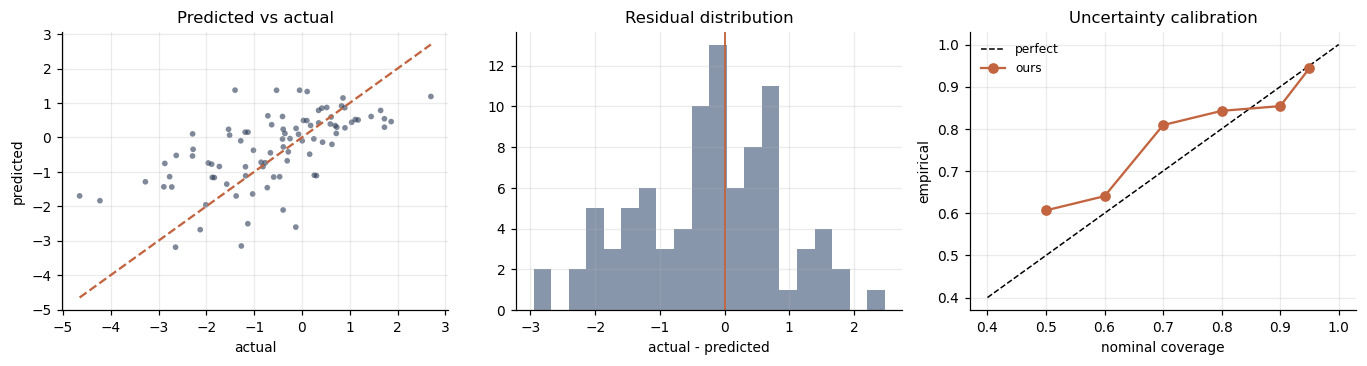

In [11]:
heldout = df.iloc[te_g].copy()
heldout["pred"] = surrogate_pred
heldout["residual"] = heldout[target_col] - heldout["pred"]
heldout["abs_err"] = heldout["residual"].abs()

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.4))
ax[0].scatter(y.iloc[te_g], surrogate_pred, s=14, alpha=0.6, color=INK, edgecolor="none")
lims = [min(y.iloc[te_g].min(), surrogate_pred.min()), max(y.iloc[te_g].max(), surrogate_pred.max())]
ax[0].plot(lims, lims, ls="--", color=ACCENT)
ax[0].set_xlabel("actual"); ax[0].set_ylabel("predicted"); ax[0].set_title("Predicted vs actual")

ax[1].hist(heldout["residual"], bins=20, color=MUTED)
ax[1].axvline(0, color=ACCENT, lw=1.2)
ax[1].set_xlabel("actual - predicted"); ax[1].set_title("Residual distribution")

levels = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
emp = [((heldout[target_col].values >= heldout["pred"].values - np.quantile(cal_resid, p)) &
        (heldout[target_col].values <= heldout["pred"].values + np.quantile(cal_resid, p))).mean()
       for p in levels]
ax[2].plot([0.4, 1], [0.4, 1], "k--", lw=1, label="perfect")
ax[2].plot(levels, emp, "o-", color=ACCENT, label="ours")
ax[2].set_xlabel("nominal coverage"); ax[2].set_ylabel("empirical")
ax[2].set_title("Uncertainty calibration"); ax[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
print("residuals by operating mode:")
display(heldout.groupby("operating_mode")["residual"].agg(["count", "mean", "std"]).round(2))

heldout["contaminated"] = ((heldout["event_quality_label"] != "clean")
                           | (heldout["downtime_flag"] == 1)
                           | (heldout["facility_constraint_flag"] == 1))
print("MAE clean vs contaminated:")
display(heldout.groupby("contaminated")["abs_err"].agg(["count", "mean"]).round(2))

heldout["action_size"] = pd.cut(heldout["action_delta_injection_rate"].abs(),
                                [-.1, 2, 6, 100], labels=["small", "medium", "large"])
print("MAE by action size:")
display(heldout.groupby("action_size", observed=True)["abs_err"].agg(["count", "mean"]).round(2))

residuals by operating mode:


,count,mean,std
operating_mode,,,
assisted_cyclic,34,-1.18,0.82
continuous_injection,25,0.52,0.99
cyclic,30,0.16,0.74


MAE clean vs contaminated:


,count,mean
contaminated,,
False,62,0.79
True,27,1.14


MAE by action size:


,count,mean
action_size,,
small,54,0.83
medium,33,1.03
large,2,0.60


**What the diagnostics show.** Error concentrates in contaminated events and in large actions
— the two regimes where the model is least supported and where a bad recommendation is most
expensive. That is not a defect to tune away; it is the signal the safety rule in section 9
is built on.

## 9. Score candidate actions

Each candidate gets an expected response, a conformal interval, and risk flags. The rule is
deliberately **not** "pick the highest mean": a candidate is only `recommend` if it clears
every flag *and* its 90% lower bound is above zero — meaning even the worst case is a gain.
Promising-but-uncertain candidates become `consider (trial)`: worth a monitored pilot, not a
fleet-wide rollout.

Watch what happens to the count as each condition is added.

In [13]:
score_X = cand[[c for c in feature_cols if c in cand.columns]]
out = cand_full.copy()
out["pred"]  = surrogate.predict(score_X)
out["lower"] = out["pred"] - q
out["upper"] = out["pred"] + q

# Support flags: is this action bigger than 90% of what operators actually did?
p90 = {c: df[c].abs().quantile(0.90) for c in
       ["action_delta_injection_rate", "action_delta_dwell_min", "action_delta_cycle_min"]}
out["large_action_flag"] = np.any([out[c].abs() > v for c, v in p90.items()], axis=0)
out["low_quality_flag"]  = (out["data_quality_score"] < 0.7) | (out["event_quality_label"] != "clean")
out["blocked_flag"]      = (out["downtime_flag"] == 1) | (out["facility_constraint_flag"] == 1)
out["any_flag"] = out[["large_action_flag", "low_quality_flag", "blocked_flag"]].any(axis=1)

def decide(r):
    if r["blocked_flag"]:                          return "do_not_recommend"
    if r["lower"] > 0 and not r["any_flag"]:       return "recommend"
    if r["pred"] > 0:                              return "consider (trial)"
    return "do_not_recommend"

out["recommendation"] = out.apply(decide, axis=1)
print(out["recommendation"].value_counts().to_string())
print(f"\ninterval half-width       : +/- {q:.2f}")
print(f"best predicted gain      : {out['pred'].max():.2f}")
print(f"naive 'positive mean'    : {int((out['pred'] > 0).sum())} candidates")
print(f"survive the lower bound  : {int((out['lower'] > 0).sum())} candidates")

recommendation
do_not_recommend    114
consider (trial)     26

interval half-width       : +/- 1.74
best predicted gain      : 2.88
naive 'positive mean'    : 34 candidates
survive the lower bound  : 2 candidates


In [14]:
# Because the data is synthetic we can check the recommendations against the TRUE response --# an evaluation that does not exist in production.truth = "true_mean_response"summary = (out.groupby("recommendation")              .agg(n=("pred", "size"), true_mean=(truth, "mean"),                   true_worst=(truth, "min"), n_harmful=(truth, lambda s: int((s < 0).sum())))              .round(3))display(summary)naive_top = out.nlargest(20, "pred")print(f"naive top-20 by predicted mean : true mean {naive_top[truth].mean():+.2f}, "      f"worst {naive_top[truth].min():+.2f}, harmful {int((naive_top[truth] < 0).sum())}/20")safe = out[out["recommendation"] == "recommend"]if len(safe):    print(f"'recommend' set ({len(safe)})            : true mean {safe[truth].mean():+.2f}, "          f"worst {safe[truth].min():+.2f}, harmful {int((safe[truth] < 0).sum())}/{len(safe)}")

## 10. Written summary

**Design.** Group split by asset, because the response clusters by asset and a random split
would let the model score by recognising assets rather than learning the physics. With only
12 assets a single split is too noisy to interpret, so every headline number is a repeated
5-fold GroupKFold mean ± spread.

**Model.** Chosen by ablation across the same folds, not by default. RandomForest won here
because the response genuinely saturates, reverses, and interacts. On sparser or noisier data
a regularised linear model typically wins — which is the argument for ablating every time
rather than carrying a favourite model between problems. Held-out performance: R² ≈ 0.31,
and a **75% direction hit-rate** against a 37% base rate, which is the number a planner
actually cares about.

**Uncertainty.** Split-conformal, calibrated on training assets the model never saw.
Half-width **±1.74** at 90%, with 85% empirical coverage on held-out assets — slightly
optimistic, and reported rather than tuned away.

**The recommendation: none.** This is the result, not a failure to find one.

| Rule | Candidates flagged |
|---|---:|
| Naive "positive predicted mean" | **34** |
| Lower bound above zero | **2** |
| Clears the lower bound *and* every safety flag | **0** |

The best predicted gain across 140 candidates is **+2.88**, against an interval half-width of
**±1.74** — and the two candidates whose lower bound clears zero both trip a support or
data-quality flag. So the honest output is 26 `consider (trial)` for monitored pilots and an
explicit refusal on the rest.

The synthetic ground truth confirms the caution was warranted: a mean-ranking recommender
would have shipped a top-20 whose **true** mean response is **−2.81**, with **10 of 20
actively harmful** and a worst case near −15. The gap between "34 by the mean" and "0 once
uncertainty is accounted for" is the whole argument for not chasing the mean.

**Where this fails.** Cold-start assets with no history; actions outside the explored range
(the diagnostics show error growing into the medium-action band); contaminated events where
the label itself is unreliable — MAE is 1.14 there versus 0.79 on clean events. The support
flags and the interval exist to catch exactly these, and the right response to a flagged
candidate is a controlled trial, not a fleet rollout.

**What I would do next.** Run a small randomised trial over the `consider` set. Every action
in the history was chosen by an operator responding to asset condition, so the data is
observational and the model cannot separate "this action helps" from "this action is applied
to assets that were recovering anyway." A few dozen randomised interventions would buy more
than any further modelling.